In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
%%time
dataset = 'kontur_population'
collection_id = 'vector-kontur-population'

# Stac collection title
collection_title = 'Kontur Population'

# Stac collection description
description = '''Kontur Population:
Global Population Density for H3 Hexagons at 400m, 3km, and 22km Resolution.
https://data.humdata.org/dataset/kontur-population-dataset'''

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'time'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'h3'
dimension_values = {}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 1e6

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

geoparquet_path = '/data/vector/kontur_population/processed/'
files = glob(os.path.join(geoparquet_path, '*.parquet'))

cols = [
    'h3',
    'time',
    'resolution',
    'population', 
    'geometry',
]

def load_clean_partial(file, cols):
    """Harmonize partial files before uploading."""
    gdf_part = geopandas.read_parquet(file)

    # set UTC timestamp
    # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
    gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

    # # Fill in missing columns
    # missing_cols = list(set(cols) - set(gdf_part.columns))
    # for col in missing_cols:
    #     gdf_part[col] = None

    gdf_part['geometry'] = gdf_part['geometry'].make_valid()

    # Order the columns uniformly
    return gdf_part[cols]

len(files)

CPU times: total: 0 ns
Wall time: 10.9 ms


37

In [3]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x21258dff110>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'kontur_population',
 'collection_id': 'vector-kontur-population',
 'temporal_levels': [],
 'dimension_values': {},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/kontur_population',
 'grid_directory': 'data/vectorstore/kontur_population/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/kontur_population/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/kontur_population/grid=World(4326)/index',
 'dt_col': 'time',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'h3',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['time', 'h3'],
 'max_level': 26,
 'target_level': 14,
 'max_depth': 14,
 'max_inflation': 100,
 'target_rows': 1000000.0,
 'row_group_size': 1

# Chunked successive ingestion

In [4]:
# %%time
# n_chunks = 1
# for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
#     print('Chunk', i)
#     vs.partial_upload(
#         chunk,
#         defrag=False,
#         index=False,
#         geometry_area=False,
#         geometry_length=False,
#     )

In [5]:
%%time
for file in files:
    print(file)
    chunk = load_clean_partial(file, cols)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

/data/vector/kontur_population/processed\kontur_population_20231101_0.0_1000000.0.parquet
df_root 1000000
Time for indexing the root of each unique geometry in seconds 8.23
distributed over 2 partitions
Time for creating partitions in seconds 4.201
Time for writing GeoDataFrame to GeoParquet partitions 7.984
/data/vector/kontur_population/processed\kontur_population_20231101_1000000.0_2000000.0.parquet
df_root 1000000
Time for indexing the root of each unique geometry in seconds 8.596
distributed over 2 partitions
Time for creating partitions in seconds 4.189
Time for writing GeoDataFrame to GeoParquet partitions 7.951
/data/vector/kontur_population/processed\kontur_population_20231101_10000000.0_11000000.0.parquet
df_root 1000000
Time for indexing the root of each unique geometry in seconds 8.894
distributed over 2 partitions
Time for creating partitions in seconds 2.892
Time for writing GeoDataFrame to GeoParquet partitions 6.547
/data/vector/kontur_population/processed\kontur_popula

In [6]:
%%time
vs.unify_schemas()

Time for unify_schemas 20.818
CPU times: total: 18.1 s
Wall time: 20.8 s


In [7]:
%%time
vs.defrag()

Time for defragging 243.137
CPU times: total: 3min 13s
Wall time: 4min 3s


In [8]:
%%time
vs.repartition({})

level 0
source partition          target partition          records stay    records move   
0q                        0q13032                   7336951         3740           
0q                        0q12000                   7277232         59719          
0q                        0q02133                   7245031         32201          
0q                        0q1302                    7082392         162639         
0q                        0q1300                    6880647         201745         
0q                        0q1220                    6870050         10597          
0q                        0q1213                    6850043         20007          
0q                        0q1211                    6849108         935            
0q                        0q1023                    6675624         173484         
0q                        0q0302                    6068203         607421         
0q                        0q0213                    5994284         

In [9]:
%%time
vs.defrag()

Time for defragging 184.82
CPU times: total: 2min 47s
Wall time: 3min 4s


In [10]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [11]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory, split_row_groups=False)
ddf

CPU times: total: 31.2 ms
Wall time: 239 ms


,h3,time,resolution,population,geometry,_root,grid,spatial_partition
npartitions=47,,,,,,,,
,object,"datetime64[ns, UTC]",object,float64,geometry,object,category[known],category[known]
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


<Axes: >

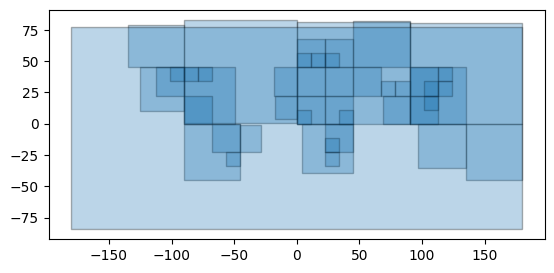

In [12]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [13]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('endpoint_url', '')
# S3 bucket
bucket = os.getenv('bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)
bucket

'claimed-test'

In [14]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [15]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [16]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
dt_start = df[vs.dt_col].min()
dt_end = df[vs.dt_col].max()

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [17]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

uploading to remote_path claimed-test/vectorstore/kontur_population/grid=World(4326)/geoparquet/spatial_partition=0q/616b22377c9845cf9ff395a28aa8bea6.parquet
schema.names ['h3', 'time', 'resolution', 'population', 'geometry', '_root']
schema.types [DataType(string), TimestampType(timestamp[ns, tz=UTC]), DataType(string), DataType(double), DataType(binary), DataType(string)]
schema.metadata [b'kontur_population', b'pandas', b'geo']
uploading to remote_path claimed-test/vectorstore/kontur_population/grid=World(4326)/geoparquet/spatial_partition=0q012/590a10d9c07b403a898ee6d0fd46063c.parquet
schema.names ['h3', 'time', 'resolution', 'population', 'geometry', '_root']
schema.types [DataType(string), TimestampType(timestamp[ns, tz=UTC]), DataType(string), DataType(double), DataType(binary), DataType(string)]
schema.metadata [b'kontur_population', b'pandas', b'geo']
uploading to remote_path claimed-test/vectorstore/kontur_population/grid=World(4326)/geoparquet/spatial_partition=0q01213/c01aa

In [18]:
vs.stac_json_folder_submitted

'data/vectorstore/kontur_population/grid=World(4326)/stac/submitted'

In [19]:
vs.stac_url

'https://stac-fastapi-sqlalchemy-nasageospatial-dev.cash.sl.cloud9.ibm.com'

In [20]:
vs.collection_id

'vector-kontur-population'